### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

https://docs.langchain.com/oss/python/langchain/middleware/overview

Middleware é uma camada intermediária que executa lógica antes, durante ou depois de uma ação de um agente ou modelo. Ele funciona como um interceptor no pipeline do agente.Ou seja, ele permite:
- observar
- modificar
- controlar
- validar

o que está acontecendo entre as etapas do sistema de IA.

Estrutura de um agente sem middleware:
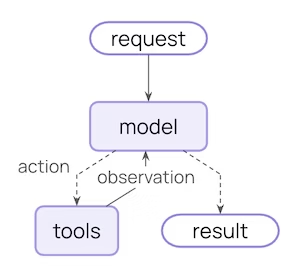

Com middleware:
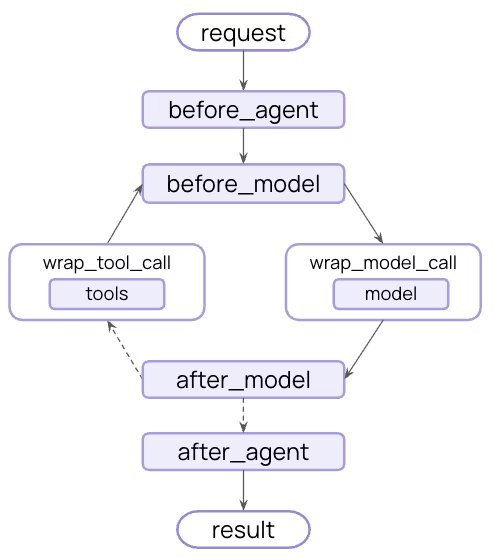

ou seja, adiciona hooks no pipeline, que são pontos onde você pode executar código e que podem inserir comportamentos personalizados.

| Hook         | Quando roda               |
| ------------ | ------------------------- |
| before_agent | antes do agente executar  |
| before_model | antes da chamada ao LLM   |
| after_model  | depois da resposta do LLM |
| before_tool  | antes de chamar uma tool  |
| after_tool   | depois da tool executar   |
| after_agent  | após a resposta final     |

Usuário -> Middleware -> Agente -> LLM -> Tool -> Resposta


#### Exemplos de Middleware

| Middleware                     | O que faz                                      | Exemplo prático                                      |
|--------------------------------|--------------------------------------------------|------------------------------------------------------|
| Logging / Observabilidade      | Registra eventos do agente ou modelo             | Log de prompts, respostas e erros                    |
| Transformação de Prompt        | Modifica o prompt antes de enviar ao LLM         | Adicionar instruções ou contexto ao prompt           |
| Guardrails / Segurança         | Filtra ou bloqueia conteúdo sensível             | Detectar CPF, e-mails ou conteúdo proibido           |
| Retry / Fallback               | Reexecuta ou troca de modelo em caso de falha    | GPT-4 falha → usar GPT-3.5                           |
| Limite de chamadas do modelo   | Controla quantas vezes o LLM pode ser chamado    | Máx. 10 chamadas ao modelo                           |
| Limite de chamadas de tools    | Controla quantas vezes ferramentas são usadas    | Limitar chamadas a APIs externas                     |
| Human-in-the-loop              | Exige aprovação humana antes de executar algo    | Aprovar execução de uma tool crítica                 |
| Compressão de histórico        | Resume histórico de conversa para economizar tokens | Após 10 mensagens → gerar resumo do histórico        |
| Pós-processamento de resposta  | Ajusta a saída antes de enviar ao usuário        | Formatar texto ou remover conteúdo sensível          |

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

### Message based summarization middleware
agent = create_agent(
    model="gpt-4o-mini",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("messages", 10),  # Trigger summarization every 10 messages
            keep=("messages", 4),  # Keep the last 4 messages in the conversation
        )
    ]
)

In [6]:
### Run with thread id
config={"configurable": {"thread_id": "thread-1"}}

In [7]:
# Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")

Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='f01d751f-2d6a-4cb6-967a-93e02d4dae3f'), AIMessage(content='2 + 2 equals 4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 14, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_7e09045385', 'id': 'chatcmpl-DINn5hcg013B1AsrFVGbowszQ1BhM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cdf5b-6458-7821-a0f0-b60b52d7b1a5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 8, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': 

## Token Size

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 550),  # Trigger summarization every 550 tokens
            keep=("tokens", 200 ),  # Keep the last 200 tokens in the conversation
        )
    ]
)

config = {"configurable": {"thread_id": "test-2"}}

# Token count function (approximate)
def count_tokens(messages):
    total_chars = sum(len(msg.content) for msg in messages)
    return total_chars // 4  # Approximate 4 characters per token

In [12]:
cities = ["New York", "Paris", "Tokyo", "Sydney", "Berlin", "London", "Sao Paulo", "Moscow"]

for city in cities:
    response = agent.invoke({"messages": [HumanMessage(content=f"Find hotels in {city}")]}, config)

    tokens = count_tokens(response["messages"])
    print(f"{city} - Tokens: {tokens}, {len(response['messages'])} messages")
    print(f"Response: {response["messages"]}\n")
    

New York - Tokens: 145, 4 messages
Response: [HumanMessage(content='Find hotels in New York', additional_kwargs={}, response_metadata={}, id='b7d2d4ed-818a-4713-a76a-c80ad6e02e25'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 54, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_202083886e', 'id': 'chatcmpl-DIO0SXMjwkrPiVmw8HVLxPfBkrD7Z', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cdf68-0e8c-7231-bf14-431742607903-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'New York'}, 'id': 'call_2wj8oqXcOAnGdcfZfKckBycJ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata

### Fraction

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens (based on context of LLM model)
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens (based on context of LLM model)
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~69 tokens (0.0539%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='2d651fec-95ca-4bd7-a82e-7c8966b8e62f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 44, 'total_tokens': 59, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1681c17ec', 'id': 'chatcmpl-DIO3PyV0exTLveR0SZPooaBTPKsb5', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cdf6a-d947-7543-afd7-daf492332969-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_0izAO2CMYlM83YDhlAgWMqEP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 44